# Clock Conversion Pipeline
Runs `pipeline/full_pipeline.py` — three modes:
1. **Single** — one digital + one analog image → output
2. **Batch** — random test-set samples side-by-side
3. **3D Clock** *(bonus)* — live 3D clock ticking at real time

In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirments.txt'


In [1]:
import os, sys

# Always run from the project root regardless of notebook location
PROJECT_ROOT = os.path.dirname(os.path.abspath('.'))
if os.path.basename(os.getcwd()) != 'DL-Project':
    os.chdir(os.path.join(os.path.dirname(os.path.abspath('.')), 'DL-Project'))
PROJECT_ROOT = os.getcwd()
sys.path.insert(0, PROJECT_ROOT)

os.makedirs('results', exist_ok=True)
print('Working dir:', PROJECT_ROOT)

Working dir: c:\Users\User\Documents\GitHub\DL-Project


In [2]:
from pipeline.full_pipeline import ClockPipeline, run_single, run_batch, run_animate
print('Pipeline imported OK')

Pipeline imported OK


## Config — edit paths here

In [3]:
READER_CKPT = 'src/checkpoints/digital_reader_best.pth'
ERASER_CKPT = 'src/checkpoints/eraser_v2_best.pth'
DATA_DIR    = 'src/clock_dataset'

# Matched pair (same timestamp prefix = same time on both clocks)
DIGITAL_IMG = 'src/clock_dataset/test/digital/00_25_39_00110_dig_simple.png'
ANALOG_IMG  = 'src/clock_dataset/test/analog/00_25_39_00110_ana_clean_square_orange_warm.png'

## Mode 1 — Single image pair

Loading pipeline on cpu ...
  [OK] Reader  — src/checkpoints/digital_reader_best.pth
  [OK] Eraser  — src/checkpoints/eraser_v2_best.pth
Pipeline ready.

  Detected time: 00:25:39
Saved output  : results/output_single.png
Saved comparison: results/output_single_comparison.png


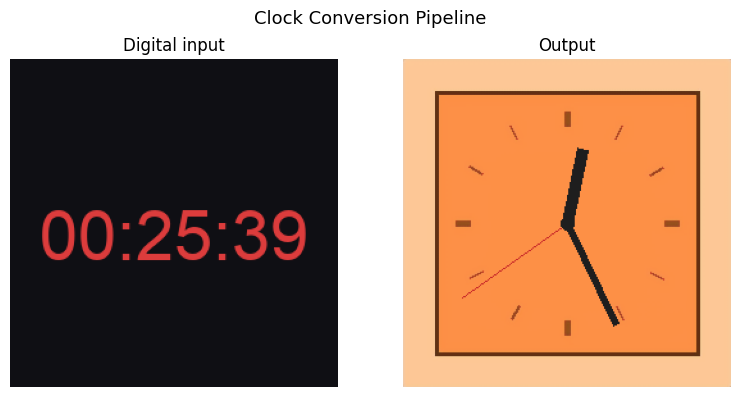

In [4]:
%matplotlib inline

run_single(
    digital_path=DIGITAL_IMG,
    analog_path=ANALOG_IMG,
    output_path='results/output_single.png',
    reader_ckpt=READER_CKPT,
    eraser_ckpt=ERASER_CKPT,
)

## Mode 2 — Batch evaluation (6 random test samples)

Loading pipeline on cpu ...
  [OK] Reader  — src/checkpoints/digital_reader_best.pth
  [OK] Eraser  — src/checkpoints/eraser_v2_best.pth
Pipeline ready.

Saved: results/batch_results.png


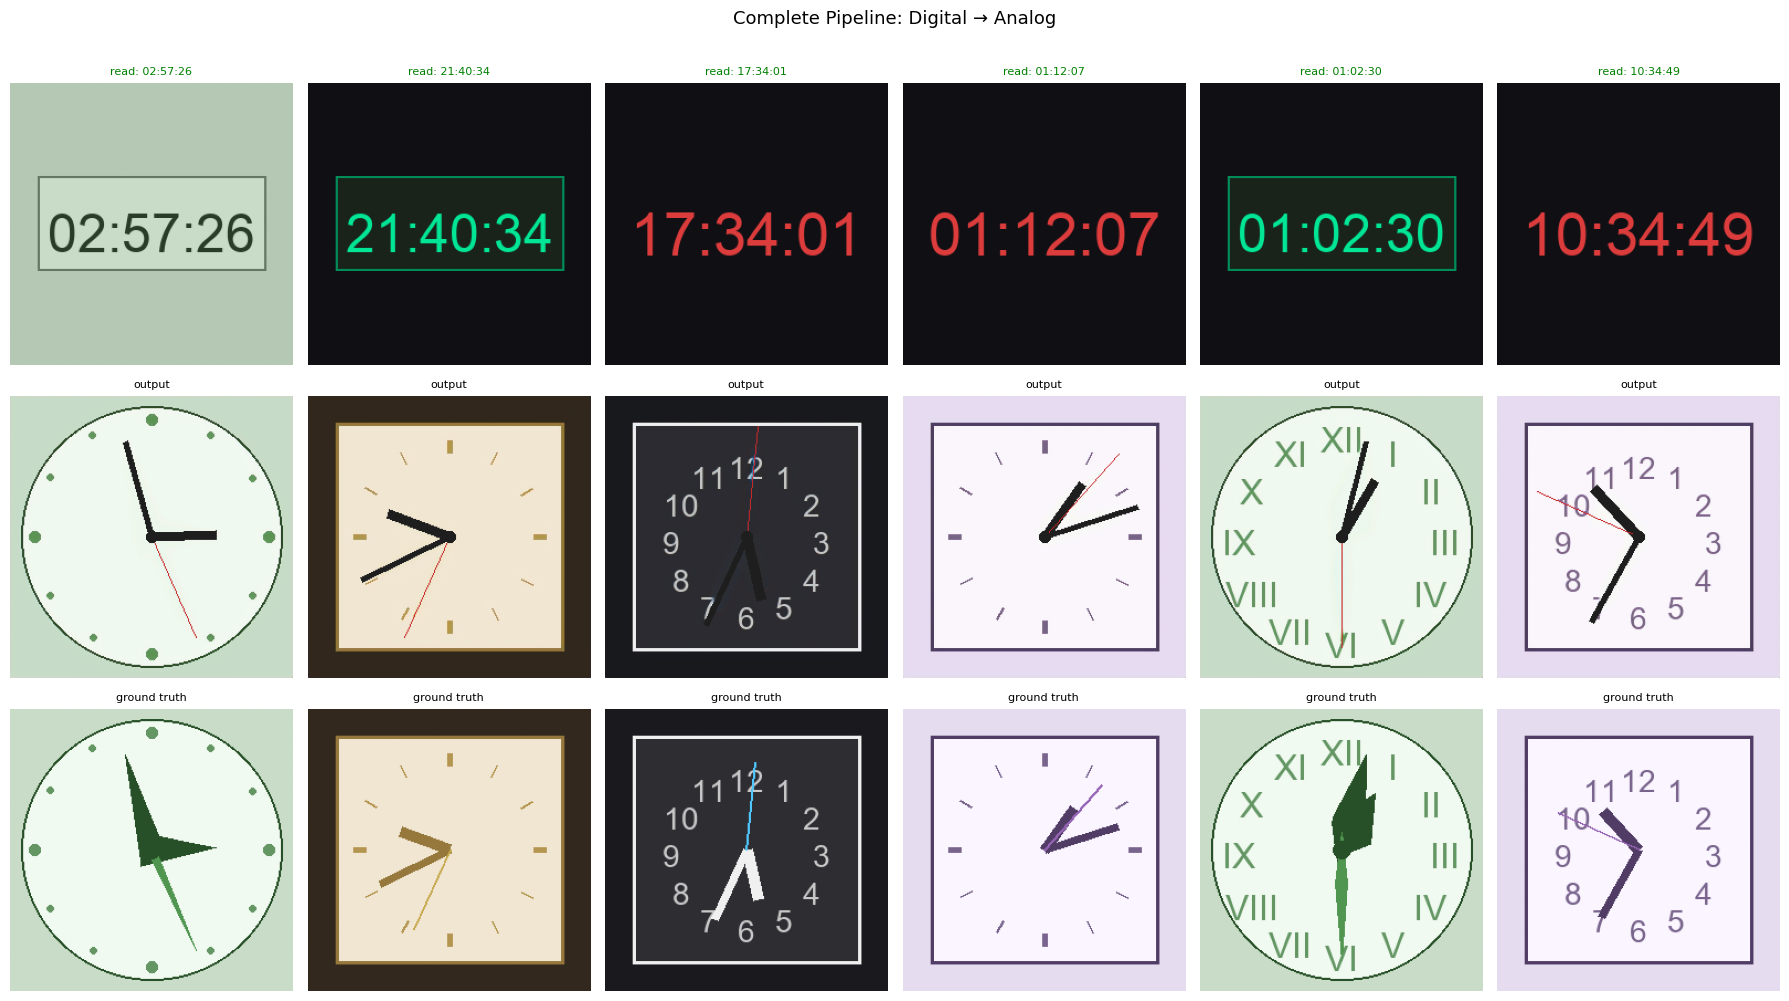

In [8]:
%matplotlib inline

run_batch(
    data_dir=DATA_DIR,
    n=6,
    output_path='results/batch_results.png',
    reader_ckpt=READER_CKPT,
    eraser_ckpt=ERASER_CKPT,
)

## Mode 3 — 3D Live Clock *(bonus)*
> Renders a 3D analog clock model ticking at real time. Stop with **Interrupt Kernel**.

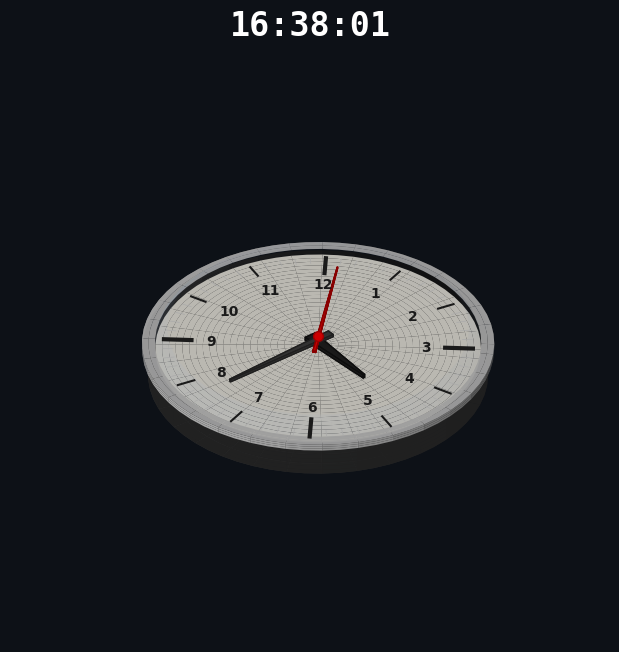

In [69]:
%matplotlib inline
import time
import math
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from IPython.display import display, clear_output
from datetime import datetime

# ── Pre-compute static clock geometry (runs once, reused every frame) ──

_N = 64
_th = np.linspace(0, 2 * np.pi, _N)

# Face disk (cream circle at z=0)
_rf = np.linspace(0, 1.0, 25)
_RF, _TF = np.meshgrid(_rf, _th)
_XF, _YF = _RF * np.cos(_TF), _RF * np.sin(_TF)

# Body cylinder (dark casing)
_zb = np.linspace(-0.18, 0.0, 8)
_TB, _ZB = np.meshgrid(_th, _zb)
_XB, _YB = 1.05 * np.cos(_TB), 1.05 * np.sin(_TB)

# Bottom cap
_rb = np.linspace(0, 1.05, 12)
_RBt, _THBt = np.meshgrid(_rb, _th)

# Bezel side + top ring
_zbz = np.linspace(0.0, 0.04, 4)
_TBZ, _ZBZ = np.meshgrid(_th, _zbz)
_rr = np.linspace(1.0, 1.08, 3)
_RR, _TR = np.meshgrid(_rr, _th)

# Glass dome
_gu = np.linspace(0, 2 * np.pi, 36)
_gv = np.linspace(0, math.pi / 8, 8)
_GU, _GV = np.meshgrid(_gu, _gv)

# Hour tick marks (bold at 12/3/6/9)
_hour_ticks = []
for _i in range(12):
    _a = math.pi / 2 - _i * math.pi / 6
    _inner = 0.78 if _i % 3 == 0 else 0.84
    _lw = 3.0 if _i % 3 == 0 else 1.5
    _hour_ticks.append((
        [_inner * math.cos(_a), 0.95 * math.cos(_a)],
        [_inner * math.sin(_a), 0.95 * math.sin(_a)],
        _lw,
    ))

# Minute tick marks
_min_ticks = []
for _i in range(60):
    if _i % 5 != 0:
        _a = math.pi / 2 - _i * math.pi / 30
        _min_ticks.append((
            [0.89 * math.cos(_a), 0.95 * math.cos(_a)],
            [0.89 * math.sin(_a), 0.95 * math.sin(_a)],
        ))

# Number label positions
_num_pos = []
for _i in range(1, 13):
    _a = math.pi / 2 - _i * math.pi / 6
    _num_pos.append((0.66 * math.cos(_a), 0.66 * math.sin(_a), str(_i)))


def _hand_3d(angle, length, z_base, half_w, thickness, tail=0.0):
    """Build an extruded 3D hand (top + bottom + 4 sides) from a tapered quad."""
    ca, sa = math.cos(angle), math.sin(angle)
    cp, sp = math.cos(angle + math.pi / 2), math.sin(angle + math.pi / 2)
    taper = 0.15
    corners = [
        [-tail * ca - half_w * cp,          -tail * sa - half_w * sp],
        [-tail * ca + half_w * cp,          -tail * sa + half_w * sp],
        [length * ca + half_w * taper * cp, length * sa + half_w * taper * sp],
        [length * ca - half_w * taper * cp, length * sa - half_w * taper * sp],
    ]
    z_top = z_base + thickness
    bot = [[*c, z_base] for c in corners]
    top = [[*c, z_top]  for c in corners]
    sides = [
        [bot[i], bot[(i+1) % 4], top[(i+1) % 4], top[i]]
        for i in range(4)
    ]
    return [bot, top] + sides


def draw_clock_3d(h, m, s):
    fig = plt.figure(figsize=(6, 6))
    fig.patch.set_facecolor('#0d1117')
    ax = fig.add_subplot(111, projection='3d')
    ax.set_facecolor('#0d1117')
    ax.computed_zorder = False

    # --- Body & face ---
    ax.plot_surface(_XB, _YB, _ZB, color='#3a3a3a', alpha=0.85, shade=True)
    ax.plot_surface(_RBt * np.cos(_THBt), _RBt * np.sin(_THBt),
                    np.full_like(_RBt, -0.18), color='#2a2a2a', alpha=0.9)
    ax.plot_surface(_XF, _YF, np.zeros_like(_RF),
                    color='#faf8ef', alpha=0.97, shade=True)

    # --- Bezel ---
    ax.plot_surface(1.08 * np.cos(_TBZ), 1.08 * np.sin(_TBZ), _ZBZ,
                    color='#c0c0c0', alpha=0.95, shade=True)
    ax.plot_surface(_RR * np.cos(_TR), _RR * np.sin(_TR),
                    np.full_like(_RR, 0.04), color='#d0d0d0', alpha=0.95)

    # --- Tick marks ---
    for xs, ys, lw in _hour_ticks:
        ax.plot(xs, ys, [0.005, 0.005], color='#1a1a1a', linewidth=lw)
    for xs, ys in _min_ticks:
        ax.plot(xs, ys, [0.005, 0.005], color='#aaaaaa', linewidth=0.5)

    # --- Numbers ---
    for nx, ny, label in _num_pos:
        ax.text(nx, ny, 0.006, label, ha='center', va='center',
                fontsize=10, fontweight='bold', color='#1a1a1a')

    # --- Hands ---
    h_ang = math.pi / 2 - (h % 12 + m / 60) * math.pi / 6
    m_ang = math.pi / 2 - (m + s / 60) * math.pi / 30
    s_ang = math.pi / 2 - s * math.pi / 30

    hand_specs = [
        (_hand_3d(h_ang, 0.45, 0.005, 0.038, 0.020, 0.08), '#1a1a1a', '#0d0d0d'),
        (_hand_3d(m_ang, 0.68, 0.027, 0.024, 0.015, 0.10), '#333333', '#1f1f1f'),
        (_hand_3d(s_ang, 0.78, 0.044, 0.009, 0.008, 0.15), '#cc0000', '#880000'),
    ]
    for faces, fcolor, ecolor in hand_specs:
        poly = Poly3DCollection(faces)
        poly.set_facecolor(fcolor)
        poly.set_edgecolor(ecolor)
        poly.set_alpha(0.95)
        ax.add_collection3d(poly)

    # --- Center cap ---
    ax.scatter([0], [0], [0.058], color='#cc0000', s=50,
               edgecolors='#990000', linewidths=1)

    # --- Glass dome ---
    ax.plot_surface(np.cos(_GU) * np.cos(_GV),
                    np.sin(_GU) * np.cos(_GV),
                    np.sin(_GV) * 0.25 + 0.04,
                    color='#a0c4ff', alpha=0.06)

    # --- Camera & styling ---
    ax.view_init(elev=35, azim=-87)
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_zlim(-0.35, 0.5)
    ax.set_box_aspect([1, 1, 0.35])
    ax.axis('off')
    ax.set_title(f'{h:02d}:{m:02d}:{s:02d}', fontsize=24, color='white',
                 pad=-10, fontweight='bold', family='monospace')
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    return fig


print("Running 3D clock for 10 seconds — interrupt kernel to stop early.")
for _ in range(9):
    now = datetime.now()
    fig = draw_clock_3d(now.hour, now.minute, now.second)
    clear_output(wait=True)
    display(fig)
    plt.close(fig)
    time.sleep(1)